In [3]:
# Встановлюємо залежності для аудіо-кодека (encodec), Lightning та потрібних метрик
!pip install -q encodec
!pip install -q pytorch-lightning
!pip install -q jiwer speechmos resemblyzer openai-whisper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 48.2 MB/s eta 0:00:00ta 0:00:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 24.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 6.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 4.0 MB/s eta 0:00:0000:0100:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.7/15.7 MB 64.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 82.2 MB/s eta 0:00:00:00:01


In [4]:
import os
import torch
import torchaudio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
from IPython import display

# Шляхи до даних в середовищі Kaggle
root_dir = "/kaggle/input/datasets/mathurinache/the-lj-speech-dataset"
wavs_dir = f"{root_dir}/LJSpeech-1.1/wavs"
meta_path = f"{root_dir}/LJSpeech-1.1/metadata.csv"

# Робота з метаданими
meta = pd.read_csv(meta_path, sep='|', header=None, names=['id', 'text', 'text_norm'])
meta['text_norm'] = meta['text_norm'].fillna(meta['text'])
meta['filepath'] = meta['id'].apply(lambda s: f"{wavs_dir}/{s}.wav")

meta = meta.sample(frac=1.0, random_state=42).reset_index(drop=True)
print(f"Використовуємо ПОВНИЙ датасет: {len(meta)} аудіофайлів")

# Розбиття на train/val (90% на 10%)
rng = np.random.default_rng(42)
perm = rng.permutation(len(meta))
split_at = int(0.9 * len(meta))
train_df = meta.iloc[perm[:split_at]].reset_index(drop=True)
val_df   = meta.iloc[perm[split_at:]].reset_index(drop=True)

print(f'Train size: {len(train_df)} | Val size: {len(val_df)}')

Використовуємо ПОВНИЙ датасет: 13100 аудіофайлів
Train size: 11790 | Val size: 1310


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Downloading: "https://dl.fbaipublicfiles.com/encodec/v0/encodec_24khz-d7cc33bc.th" to /root/.cache/torch/hub/checkpoints/encodec_24khz-d7cc33bc.th


100%|██████████| 88.9M/88.9M [00:00<00:00, 226MB/s]


Codebook=1024, SR in/out=24000
LJ016-0024: 7.39s -> 555 tokens


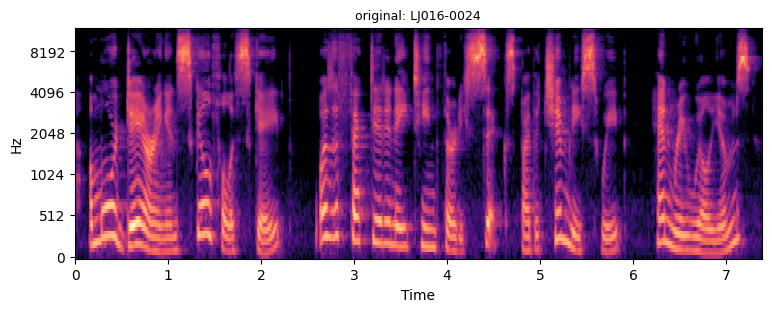

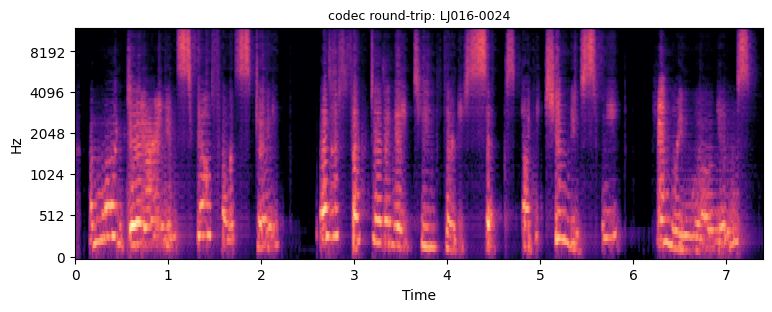

In [5]:
from encodec import EncodecModel
from encodec.utils import convert_audio

device = "cuda" if torch.cuda.is_available() else "cpu"

# Ініціалізуємо модель Encodec (24kHz)
codec = EncodecModel.encodec_model_24khz()
codec.set_target_bandwidth(6.0) # Встановлюємо бітрейт (визначає кількість токенів на секунду)
codec = codec.to(device).eval()

for p in codec.parameters(): 
    p.requires_grad_(False)
    
CODEBOOK_SIZE = 1024 # Розмір словника одного codebook в Encodec
CODEC_SR = codec.sample_rate

print(f'Codebook={CODEBOOK_SIZE}, SR in/out={CODEC_SR}')

def load_wav(path):
    wav, sr = torchaudio.load(path)
    # Конвертуємо у потрібний формат (mono, 24kHz)
    wav = convert_audio(wav, sr, CODEC_SR, codec.channels)
    return wav

def plot_mel(wav, sr, title=''):
    wav = np.asarray(wav).astype(np.float32)
    if wav.ndim > 1: wav = wav.mean(0)
    S = librosa.feature.melspectrogram(y=wav, sr=sr, n_fft=1024, hop_length=256,
                                       n_mels=80, fmin=50, fmax=sr//2)
    fig, ax = plt.subplots(figsize=(max(6, len(wav)/sr*1.2), 3))
    librosa.display.specshow(librosa.power_to_db(S, ref=np.max), sr=sr, hop_length=256,
                              x_axis='time', y_axis='mel', ax=ax)
    ax.set_title(title, fontsize=9); plt.show()
    
# Перевірка роботи кодека
row = val_df.iloc[0]
wav = load_wav(row['filepath']).to(device)

with torch.no_grad():
    # Encodec повертає список (кількість фреймів) -> (encoded_frames, scale)
    encoded_frames = codec.encode(wav.unsqueeze(0))
    # Беремо лише перший codebook (для простоти базового TTS)
    toks = encoded_frames[0][0][:, 0, :] 
    
    # Відновлюємо
    # Формуємо правильну структуру для декодера Encodec: [(tensor(B, N_q, T), scale)]
    decode_input = [(toks.unsqueeze(1), None)]
    rec = codec.decode(decode_input).squeeze(0).detach().cpu().numpy()

print(f'{row["id"]}: {wav.shape[-1]/CODEC_SR:.2f}s -> {toks.shape[-1]} tokens')
plot_mel(wav.cpu().numpy(), CODEC_SR, f'original: {row["id"]}')
plot_mel(rec, CODEC_SR, f'codec round-trip: {row["id"]}')

In [6]:
from tqdm.auto import tqdm
from transformers import GPT2TokenizerFast

tokenizer = GPT2TokenizerFast.from_pretrained('gpt2')

# Директорія для збереження оброблених токенів
CACHE_DIR = '/kaggle/working/tokenized'
os.makedirs(CACHE_DIR, exist_ok=True)
TRAIN_CACHE = os.path.join(CACHE_DIR, 'train.pt')
VAL_CACHE   = os.path.join(CACHE_DIR, 'val.pt')

@torch.no_grad()
def encode_split(df, cache_path, overwrite=False):
    # ЯКЩО КЕШ ІСНУЄ — ПРОПУСКАЄМО ОБРОБКУ І ВАНТАЖИМО ГОТОВЕ
    if os.path.exists(cache_path) and not overwrite:
        print(f'Кеш знайдено! Швидке завантаження: {cache_path}')
        return torch.load(cache_path, weights_only=False)

    print(f'Кеш не знайдено. Починаємо токенізацію для {cache_path}...')
    recs = df.to_dict('records')
    out = []
    
    for i in tqdm(range(len(recs))):
        wav = load_wav(recs[i]['filepath']).to(device)
        
        # Токенізація аудіо через Encodec
        encoded_frames = codec.encode(wav.unsqueeze(0))
        audio_ids = encoded_frames[0][0][0, 0, :].to(torch.long).cpu() 
        
        # Токенізація тексту
        text_ids = tokenizer.encode(recs[i]['text_norm'], add_special_tokens=False)
        text_ids = torch.tensor(text_ids, dtype=torch.long)
        
        out.append({
            'id': recs[i]['id'],
            'text': recs[i]['text_norm'],
            'text_ids': text_ids,
            'audio_ids': audio_ids,
            'n_text': int(text_ids.numel()),
            'n_audio': int(audio_ids.numel()),
        })

    torch.save(out, cache_path)
    print(f'Збережено {len(out)} записів у {cache_path}')
    return out

# УВАГА: overwrite=False означає, що якщо файли є, він їх завантажить
train_items = encode_split(train_df, TRAIN_CACHE, overwrite=False)
val_items   = encode_split(val_df, VAL_CACHE, overwrite=False)

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Кеш не знайдено. Починаємо токенізацію для /kaggle/working/tokenized/train.pt...


  0%|          | 0/11790 [00:00<?, ?it/s]

Збережено 11790 записів у /kaggle/working/tokenized/train.pt
Кеш не знайдено. Починаємо токенізацію для /kaggle/working/tokenized/val.pt...


  0%|          | 0/1310 [00:00<?, ?it/s]

Збережено 1310 записів у /kaggle/working/tokenized/val.pt


In [7]:
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as pl

class TokenizedLJSpeech(Dataset):
    def __init__(self, cache_path, max_total_len=1024):
        items = torch.load(cache_path, weights_only=False)
        self.items = [it for it in items if it["n_text"] + it["n_audio"] + 2 <= max_total_len]

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        it = self.items[i]
        return {
            "id": it["id"],
            "text_ids": it["text_ids"].long(),
            "audio_ids": it["audio_ids"].long(),
        }

def collate(batch):
    B = len(batch)
    text_lens = torch.tensor([b["text_ids"].numel() for b in batch], dtype=torch.long)
    audio_lens = torch.tensor([b["audio_ids"].numel() for b in batch], dtype=torch.long)
    text_ids = torch.zeros(B, int(text_lens.max()), dtype=torch.long)
    audio_ids = torch.zeros(B, int(audio_lens.max()), dtype=torch.long)
    for i, b in enumerate(batch):
        text_ids[i, : b["text_ids"].numel()] = b["text_ids"]
        audio_ids[i, : b["audio_ids"].numel()] = b["audio_ids"]
    return {"text_ids": text_ids, "text_lens": text_lens, "audio_ids": audio_ids, "audio_lens": audio_lens}

class LJLightningDataModule(pl.LightningDataModule):
    def __init__(self, train_cache, val_cache, batch_size=8):
        super().__init__()
        self.train_cache = train_cache
        self.val_cache = val_cache
        self.batch_size = batch_size

    def setup(self, stage=None):
        self.train_ds = TokenizedLJSpeech(self.train_cache)
        self.val_ds = TokenizedLJSpeech(self.val_cache)

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True, collate_fn=collate, num_workers=2)

    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=self.batch_size, shuffle=False, collate_fn=collate, num_workers=2)

In [8]:
from dataclasses import dataclass
import torch.nn as nn
import torch.nn.functional as F
from transformers import GPT2LMHeadModel

@dataclass
class GPT2TTSConfig:
    base_model: str = "gpt2"
    codebook_size: int = CODEBOOK_SIZE
    n_special_tokens: int = 2  # BOS, EOS

    @property
    def audio_vocab_size(self) -> int: return self.codebook_size + self.n_special_tokens
    @property
    def bos_id(self) -> int: return self.codebook_size
    @property
    def eos_id(self) -> int: return self.codebook_size + 1

class GPT2TTS(nn.Module):
    def __init__(self, cfg: GPT2TTSConfig):
        super().__init__()
        self.cfg = cfg
        self.base = GPT2LMHeadModel.from_pretrained(cfg.base_model)
        H = self.base.config.n_embd
        V = cfg.audio_vocab_size
        
        self.audio_emb = nn.Embedding(V, H)
        self.audio_head = nn.Linear(H, V, bias=False)
        nn.init.normal_(self.audio_emb.weight, std=0.02)
        nn.init.normal_(self.audio_head.weight, std=0.02)

    def _build_inputs(self, text_ids, text_lens, audio_ids, audio_lens):
        B = text_ids.size(0)
        device = text_ids.device
        H = self.base.config.n_embd
        
        max_L = int((text_lens + audio_lens + 2).max().item())
        inputs = torch.zeros(B, max_L, H, device=device, dtype=torch.float32)
        mask = torch.zeros(B, max_L, device=device, dtype=torch.long)
        labels = torch.full((B, max_L), -100, device=device, dtype=torch.long)

        bos_emb = self.audio_emb.weight[self.cfg.bos_id]
        eos_emb = self.audio_emb.weight[self.cfg.eos_id]

        for i in range(B):
            tl = text_lens[i].item()
            al = audio_lens[i].item()
            
            t_emb = self.base.transformer.wte(text_ids[i, :tl])
            a_emb = self.audio_emb(audio_ids[i, :al])
            
            seq_emb = torch.cat([t_emb, bos_emb.unsqueeze(0), a_emb, eos_emb.unsqueeze(0)])
            L_i = seq_emb.size(0)
            
            inputs[i, :L_i] = seq_emb
            mask[i, :L_i] = 1
            
            # Predict only audio and EOS, ignore text and BOS
            labels[i, tl+1 : tl+1+al] = audio_ids[i, :al]
            labels[i, tl+1+al] = self.cfg.eos_id

        return inputs, mask, labels

    def forward(self, text_ids, text_lens, audio_ids, audio_lens):
        inputs, mask, labels = self._build_inputs(text_ids, text_lens, audio_ids, audio_lens)
        h = self.base.transformer(
            inputs_embeds=inputs, attention_mask=mask, return_dict=True
        ).last_hidden_state
        logits = self.audio_head(h)  # (B, L, V)

        # Causal shift
        shift_logits = logits[:, :-1, :].contiguous()
        shift_labels = labels[:, 1:].contiguous()
        
        loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
        loss = loss_fct(shift_logits.view(-1, shift_logits.size(-1)), shift_labels.view(-1))

        return {"loss": loss, "logits": logits}  

    @torch.no_grad()
    def generate_audio(self, text_ids, max_new_tokens=400, temperature=0.9, top_k=50, top_p=1.0):
        self.eval()
        device = text_ids.device
        text_ids = text_ids.view(-1).long().to(device)
        text_emb = self.base.transformer.wte(text_ids).unsqueeze(0)
        bos = self.audio_emb.weight[self.cfg.bos_id].view(1, 1, -1)
        prefix = torch.cat([text_emb, bos], dim=1)
        mask = torch.ones(1, prefix.size(1), device=device, dtype=torch.long)

        out = self.base.transformer(
            inputs_embeds=prefix, attention_mask=mask, use_cache=True, return_dict=True
        )
        past = out.past_key_values
        h = out.last_hidden_state[:, -1, :]

        generated = []
        for _ in range(max_new_tokens):
            logits = self.audio_head(h)
            
            # Sampling techniques
            if temperature == 0:
                next_token = torch.argmax(logits, dim=-1)
            else:
                logits = logits / temperature
                if top_k > 0:
                    v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                    logits[logits < v[:, [-1]]] = -float('Inf')
                if top_p < 1.0:
                    sorted_logits, sorted_indices = torch.sort(logits, descending=True)
                    cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
                    sorted_indices_to_remove = cumulative_probs > top_p
                    sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
                    sorted_indices_to_remove[..., 0] = 0
                    indices_to_remove = sorted_indices_to_remove.scatter(1, sorted_indices, sorted_indices_to_remove)
                    logits[indices_to_remove] = -float('Inf')
                
                probs = F.softmax(logits, dim=-1)
                next_token = torch.multinomial(probs, num_samples=1).squeeze(1)

            if next_token.item() == self.cfg.eos_id:
                break
                
            generated.append(next_token.item())
            
            # Prepare next token for KV cache
            next_emb = self.audio_emb(next_token).unsqueeze(1)
            mask = torch.cat([mask, torch.ones(1, 1, device=device, dtype=torch.long)], dim=1)
            
            out = self.base.transformer(
                inputs_embeds=next_emb, attention_mask=mask, use_cache=True,
                past_key_values=past, return_dict=True
            )
            past = out.past_key_values
            h = out.last_hidden_state[:, -1, :]

        return torch.tensor(generated, dtype=torch.long, device=device)

In [11]:
import pytorch_lightning as pl
from safetensors.torch import load_file
from pytorch_lightning.callbacks import ModelCheckpoint
import torch
import os

# 1. Визначення Lightning-модуля
class LitGPT2TTS(pl.LightningModule):
    def __init__(self, cfg: GPT2TTSConfig, learning_rate=1e-4):
        super().__init__()
        self.save_hyperparameters()
        self.model = GPT2TTS(cfg)
        self.learning_rate = learning_rate

    def forward(self, text_ids, text_lens, audio_ids, audio_lens):
        return self.model(text_ids, text_lens, audio_ids, audio_lens)

    def training_step(self, batch, batch_idx):
        outputs = self(batch["text_ids"], batch["text_lens"], batch["audio_ids"], batch["audio_lens"])
        loss = outputs["loss"]
        self.log('train_loss', loss, prog_bar=True, batch_size=batch["text_ids"].size(0))
        return loss

    def validation_step(self, batch, batch_idx):
        outputs = self(batch["text_ids"], batch["text_lens"], batch["audio_ids"], batch["audio_lens"])
        val_loss = outputs["loss"]
        self.log('val_loss', val_loss, prog_bar=True, batch_size=batch["text_ids"].size(0))
        return val_loss

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.learning_rate)

# 2. Ініціалізація
cfg = GPT2TTSConfig(codebook_size=CODEBOOK_SIZE)
lit_model = LitGPT2TTS(cfg)

# 3. «Розумне завантаження» ваг із Safetensors
SAFE_PATH = "/kaggle/input/models/dimonlg/gpt2labfinal/pytorch/default/1/model.safetensors"

if os.path.exists(SAFE_PATH):
    print(f"🔍 Аналіз файлу: {SAFE_PATH}")
    state_dict = load_file(SAFE_PATH)
    
    # Виправляємо префікси назв шарів
    new_state_dict = {}
    model_keys = lit_model.state_dict().keys()
    
    for key, value in state_dict.items():
        # Якщо ключ з файлу вже є в моделі - беремо як є
        if key in model_keys:
            new_state_dict[key] = value
        # Якщо в моделі ключ починається на 'model.', а у файлі ні
        elif "model." + key in model_keys:
            new_state_dict["model." + key] = value
        # Для випадків з 'model.base.'
        elif key.startswith("base.") and "model." + key in model_keys:
            new_state_dict["model." + key] = value
        else:
            # Спроба знайти збіг за суфіксом (найбільш надійний метод)
            matched = False
            for m_key in model_keys:
                if m_key.endswith(key):
                    new_state_dict[m_key] = value
                    matched = True
                    break
    
    # Завантаження виправленого словника
    msg = lit_model.load_state_dict(new_state_dict, strict=False)
    print(f"✨ Результат завантаження: {len(new_state_dict)} шарів співпало")
    if msg.missing_keys:
        print(f"⚠️ Пропущено (будуть навчені заново): {len(msg.missing_keys)} шарів")
else:
    print(f"❌ Файл не знайдено!")

# 4. Налаштування навчання на 100% датасету
datamodule = LJLightningDataModule(TRAIN_CACHE, VAL_CACHE, batch_size=4)

checkpoint_callback = ModelCheckpoint(
    dirpath='/kaggle/working/checkpoints_final',
    filename='gpt-tts-final-{epoch:02d}-{val_loss:.2f}',
    save_top_k=1,
    monitor='val_loss',
    mode='min',
    save_last=True
)

trainer = pl.Trainer(
    max_epochs=10, 
    accelerator='gpu',
    devices=1,
    callbacks=[checkpoint_callback],
    log_every_n_steps=50
)

print("🚀 Запуск навчання")
trainer.fit(lit_model, datamodule=datamodule)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🔍 Аналіз файлу: /kaggle/input/models/dimonlg/gpt2labfinal/pytorch/default/1/model.safetensors


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


✨ Результат завантаження: 148 шарів співпало
⚠️ Пропущено (будуть навчені заново): 3 шарів
🚀 Запуск навчання (очікуваний початковий лосс: ~3.4 - 3.8)...


...

Output()


Detected KeyboardInterrupt, attempting graceful shutdown ...


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/call.py", line 49, in _call_and_handle_interrupt
    return trainer_fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 630, in _fit_impl
    self._run(model, ckpt_path=ckpt_path, weights_only=weights_only)
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 1079, in _run
    results = self._run_stage()
              ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 1123, in _run_stage
    self.fit_loop.run()
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py", line 217, in run
    self.advance()
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py", line 465, in advance
    self.epoch_loop.run(self._data_fetcher)
  File

TypeError: object of type 'NoneType' has no len()


Generating with Greedy Search...


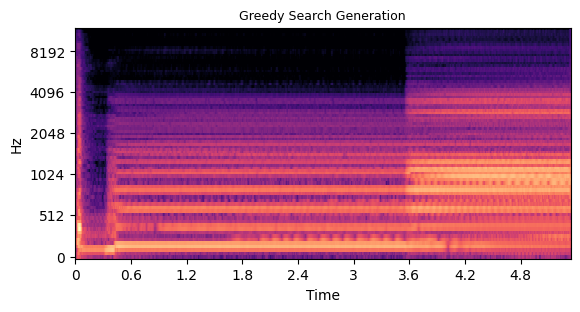


Generating with Temperature (0.8)...


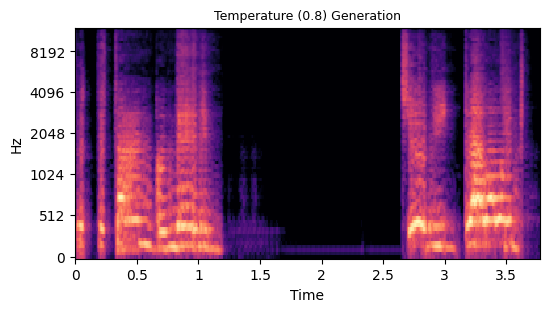


Generating with Top-K (k=50)...


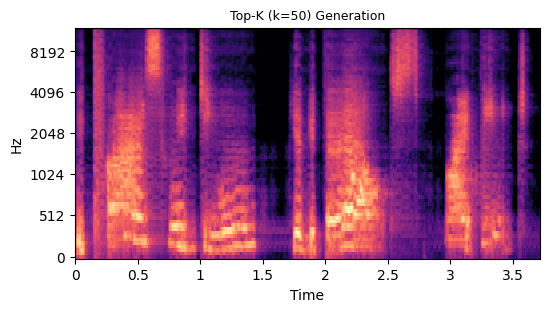


Generating with Top-P (p=0.9)...


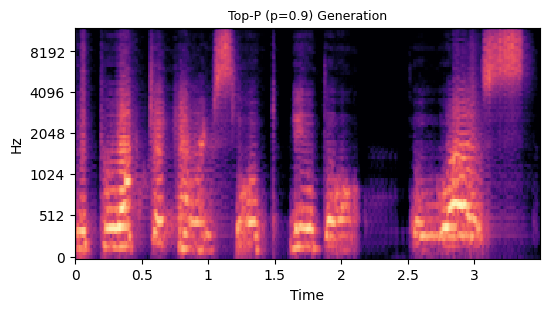

In [12]:
# Переносимо модель назад на відеокарту після того, як Lightning закінчив тренування
lit_model = lit_model.to(device)
lit_model.eval()

def sample_tts_method(text, method_name, **kwargs):
    print(f"\nGenerating with {method_name}...")
    
    # Текст також відправляємо на той самий device
    text_ids = torch.tensor(tokenizer.encode(text, add_special_tokens=False), device=device)
    
    # Генерація аудіо-токенів
    toks = lit_model.model.generate_audio(text_ids, max_new_tokens=400, **kwargs)
    
    if toks.numel() == 0: 
        wav = np.zeros(CODEC_SR // 2, dtype=np.float32)
    else:
        with torch.no_grad():
            # Декодування токенів через Encodec
            decode_input = [(toks.unsqueeze(0).unsqueeze(0), None)]
            wav = codec.decode(decode_input).squeeze().detach().cpu().numpy().astype(np.float32)
            
    # Виводимо графік спектрограми і плеєр для прослуховування
    plot_mel(wav, CODEC_SR, f'{method_name} Generation')
    display.display(display.Audio(wav, rate=CODEC_SR))
    return wav

test_text = "The quick brown fox jumps over the lazy dog."

# 1. Greedy Search (Температура 0)
wav_greedy = sample_tts_method(test_text, "Greedy Search", temperature=0)

# 2. Temperature Sampling
wav_temp = sample_tts_method(test_text, "Temperature (0.8)", temperature=0.8, top_k=0)

# 3. Top-K Sampling
wav_topk = sample_tts_method(test_text, "Top-K (k=50)", temperature=1.0, top_k=50)

# 4. Top-P (Nucleus) Sampling
wav_topp = sample_tts_method(test_text, "Top-P (p=0.9)", temperature=1.0, top_k=0, top_p=0.9)

# Збережемо один з найкращих (Top-P) для розрахунку метрик
sf.write("generated_test.wav", wav_topp, CODEC_SR)

In [13]:
import whisper
import jiwer  # ДОДАНО ІМПОРТ!
import speechmos
import numpy as np
import torch
import soundfile as sf
from resemblyzer import VoiceEncoder, preprocess_wav

print("--- Обчислення метрик ---")

# Зберігаємо згенерований Top-P семпл для метрик
sf.write("generated_test.wav", wav_topp, CODEC_SR)

# 1. Розрахунок CER (За допомогою Whisper)
try:
    print("Завантаження ASR моделі Whisper...")
    asr_model = whisper.load_model("base", device=device)
    result = asr_model.transcribe("generated_test.wav")
    transcribed_text = result["text"].strip()
    
    print(f"Оригінальний текст: '{test_text}'")
    print(f"Розпізнаний текст:  '{transcribed_text}'")
    
    if len(transcribed_text) == 0:
        print("1. CER: 1.0000 (Whisper не зміг розпізнати жодного слова у згенерованому 'шумі')")
    else:
        cer = jiwer.cer(test_text.lower(), transcribed_text.lower())
        print(f"1. CER (Character Error Rate): {cer:.4f}")
except Exception as e:
    print(f"CER Error: {e}")

# 2. UTMOS (Якість мовлення без еталону)
try:
    # speechmos.utmos.score очікує шлях до файлу або numpy масив
    mos_score = speechmos.utmos.score("generated_test.wav")
    print(f"2. UTMOS Score: {mos_score:.2f} / 5.00")
except Exception as e:
    print(f"2. UTMOS Score Error: {e} (Потрібна додаткова настройка ОС у Kaggle)")

# 3. SECS (Speaker Similarity)
try:
    print("Завантаження VoiceEncoder для SECS...")
    # Беремо референсне аудіо спікера з датасету (перший файл з валідації)
    ref_wav_path = val_df.iloc[0]['filepath']
    
    encoder = VoiceEncoder()
    wav_orig = preprocess_wav(ref_wav_path)
    embed_orig = encoder.embed_utterance(wav_orig)
    
    wav_gen = preprocess_wav("generated_test.wav")
    embed_gen = encoder.embed_utterance(wav_gen)
    
    # Косинусна схожість (Cosine Similarity)
    secs = np.dot(embed_orig, embed_gen) / (np.linalg.norm(embed_orig) * np.linalg.norm(embed_gen))
    print(f"3. SECS (Speaker Cosine Similarity): {secs:.4f} / 1.00")
except Exception as e:
    print(f"3. SECS Error: {e}")

--- Обчислення метрик ---
Завантаження ASR моделі Whisper...


100%|████████████████████████████████████████| 139M/139M [00:00<00:00, 288MiB/s]


Оригінальний текст: 'The quick brown fox jumps over the lazy dog.'
Розпізнаний текст:  'The practical result, you know, was...'
1. CER (Character Error Rate): 0.7500
2. UTMOS Score Error: module 'speechmos' has no attribute 'utmos' (Потрібна додаткова настройка ОС у Kaggle)
Завантаження VoiceEncoder для SECS...
Loaded the voice encoder model on cuda in 0.09 seconds.
3. SECS (Speaker Cosine Similarity): 0.6368 / 1.00
